<a href="https://colab.research.google.com/github/NabilBADRI/Competition-StanceNakba-2026/blob/main/NLP-Competition-StanceNakba%202026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML model

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import re
import string
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import model_selection, naive_bayes, svm
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report as creport
from sklearn.model_selection import train_test_split

from multiprocessing import Pool

In [6]:
df=pd.read_csv('/content/drive/MyDrive/Competition-StanceNakba 2026/Subtask_B_train.csv')


In [7]:
# Count the occurrences of each stance_label
print(df['stance_label'].value_counts())

stance_label
against    298
pro        286
neutral    259
Name: count, dtype: int64


In [9]:
# Or specifically for 'against'
print(df[df['stance_label'] == 'against'].shape[0])

298


In [10]:
df['stance_label'].value_counts()

,count
stance_label,
against,298
pro,286
neutral,259


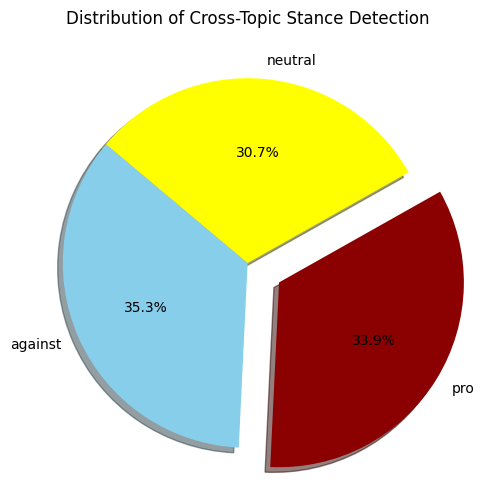

In [12]:
import matplotlib.pyplot as plt

# Get value counts
stance_counts = df['stance_label'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
explode = (0, 0.2, 0)  # Adjust based on number of categories (pro, against, neutral)

# Create pie chart
stance_counts.plot(kind='pie', autopct='%1.1f%%', explode=explode,
                   startangle=140, shadow=True,
                   colors=['skyblue', 'darkred', 'yellow'])

plt.title('Distribution of Cross-Topic Stance Detection')
plt.ylabel('')  # Remove the column name from appearing beside the pie chart
plt.show()

In [13]:

#Nouveau code---
# ===============================
# 1. ANALYSE AVANT LE NETTOYAGE
# ===============================
print("=" * 60)
print("ANALYSE AVANT LE NETTOYAGE")
print("=" * 60)
# Afficher les statistiques de base
print("\n1. Statistiques de base des données brutes :")
print("-" * 40)
print(f"Nombre total de tweets : {len(df)}")
print(f"Colonnes disponibles : {list(df.columns)}")
print(f"\nTypes de données :")
print(df.dtypes)


ANALYSE AVANT LE NETTOYAGE

1. Statistiques de base des données brutes :
----------------------------------------
Nombre total de tweets : 843
Colonnes disponibles : ['Sentence', 'Topic', 'stance_label']

Types de données :
Sentence        object
Topic           object
stance_label    object
dtype: object


In [14]:
# Afficher les premières lignes
print("\n2. Aperçu des données brutes (5 premières lignes) :")
print("-" * 40)
print(df.head())


2. Aperçu des données brutes (5 premières lignes) :
----------------------------------------
                                            Sentence  \
0  انا من فلسطين واتمنى أنهم العراقيين يجو لا عنا...   
1           التطبيع مع إسرائيل سيكون خير ان شاء الله   
2  نباح الاخونج والمرتزقة واذنابهم زاد نباحهم عال...   
3  في الاردن ان لم تسعكم الارض تسعكم عيوننا لكم م...   
4              افضل شعب الشعب السوري اختكم من الأردن   

                                               Topic stance_label  
0  وجود اللاجئين والمهاجرين في الأردن  (من فلسطين...          pro  
1                                 التطبيع مع اسرائيل          pro  
2                                 التطبيع مع اسرائيل      neutral  
3  وجود اللاجئين والمهاجرين في الأردن  (من فلسطين...          pro  
4  وجود اللاجئين والمهاجرين في الأردن  (من فلسطين...          pro  


In [ ]:
# Afficher la distribution initiale des stances
print("\n3. Distribution initiale des stances :")
print("-" * 40)
initial_counts = df['stance_label'].value_counts()
print(initial_counts)
print(f"\nProportions :")
print(initial_counts / len(df) * 100)


3. Distribution initiale des stances :
----------------------------------------
stance_label
against    298
pro        286
neutral    259
Name: count, dtype: int64

Proportions :
stance_label
against    35.349941
pro        33.926453
neutral    30.723606
Name: count, dtype: float64


In [ ]:
# Afficher des exemples de chaque catégorie
print("\n4. Exemples de tweets par catégorie :")
print("-" * 40)
for stance in df['stance_label'].unique():
    print(f"\n{stance.upper()} - Exemple :")
    sample = df[df['stance_label'] == stance]['Sentence'].iloc[0]
    print(f"  \"{sample[:100]}...\"" if len(sample) > 100 else f"  \"{sample}\"")


4. Exemples de tweets par catégorie :
----------------------------------------

PRO - Exemple :
  "انا من فلسطين واتمنى أنهم العراقيين يجو لا عنا أهلا وسهلا في كل عراقي ياجماعه عراقي وسوري كلنا اخوة ..."

NEUTRAL - Exemple :
  "نباح الاخونج والمرتزقة واذنابهم زاد نباحهم عالبحرين والامارات .. ولكن تطبيع الاردن ومصر وقطر وتركيا ..."

AGAINST - Exemple :
  "والله لو تصيحون الى ان تنشف حلوقكم مافيه تطبيع معكم  ،،،،"



5. Visualisation de la distribution initiale :
----------------------------------------


([0, 1, 2], [Text(0, 0, 'against'), Text(1, 0, 'pro'), Text(2, 0, 'neutral')])

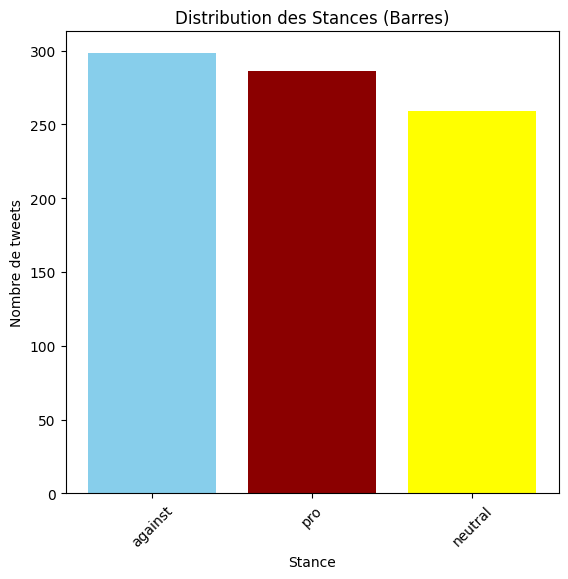

In [ ]:
# Visualisation AVANT
print("\n5. Visualisation de la distribution initiale :")
print("-" * 40)

plt.figure(figsize=(14, 6))
# Premier subplot - Diagramme en barres
plt.subplot(1, 2, 1)
bars = plt.bar(initial_counts.index, initial_counts.values,
               color=['skyblue', 'darkred', 'yellow'])
plt.title('Distribution des Stances (Barres)')
plt.xlabel('Stance')
plt.ylabel('Nombre de tweets')
plt.xticks(rotation=45)

In [ ]:
# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}', ha='center', va='bottom')

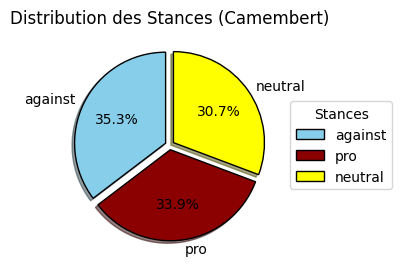

In [ ]:
# Deuxième subplot - Diagramme circulaire
plt.subplot(1, 2, 2)
explode_initial = [0.05 for _ in range(len(initial_counts))]
wedges, texts, autotexts = plt.pie(initial_counts.values,
                                    labels=initial_counts.index,
                                    autopct='%1.1f%%',
                                    explode=explode_initial,
                                    startangle=90,
                                    colors=['skyblue', 'darkred', 'yellow'],
                                    shadow=True,
                                    wedgeprops={'edgecolor': 'black'})

plt.title('Distribution des Stances (Camembert)')
plt.legend(wedges, initial_counts.index, title="Stances", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)

In [ ]:
# ===============================
# 2. NETTOYAGE DES DONNÉES
# ===============================
print("\n\nTRAITEMENT DES DONNÉES EN COURS...")
print("=" * 60)

# Créer une copie pour le nettoyage
df_clean = df.copy()



TRAITEMENT DES DONNÉES EN COURS...


In [ ]:
# Exemples de traitements (à adapter selon vos besoins)
print("1. Suppression des valeurs manquantes...")
initial_len = len(df_clean)
df_clean = df_clean.dropna()
print(f"   {initial_len - len(df_clean)} lignes supprimées")
print("2. Suppression des doublons...")
initial_len = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Sentence'])
print(f"   {initial_len - len(df_clean)} doublons supprimés")

print("3. Normalisation du texte...")
print("   - Suppression des espaces superflus")
df_clean['Sentence'] = df_clean['Sentence'].str.strip()
print("   - Conversion en minuscules")
df_clean['Sentence'] = df_clean['Sentence'].str.lower()

print("\nTraitement terminé !")
print("=" * 60)

1. Suppression des valeurs manquantes...
   0 lignes supprimées
2. Suppression des doublons...
   1 doublons supprimés
3. Normalisation du texte...
   - Suppression des espaces superflus
   - Conversion en minuscules

Traitement terminé !


In [ ]:
# ===============================
# 3. ANALYSE APRÈS LE NETTOYAGE
# ===============================
print("\n\nANALYSE APRÈS LE NETTOYAGE")
print("=" * 60)

print(f"\nNombre total de tweets après nettoyage : {len(df_clean)}")
print(f"Réduction : {len(df) - len(df_clean)} tweets ({((len(df) - len(df_clean))/len(df)*100):.1f}%)")



ANALYSE APRÈS LE NETTOYAGE

Nombre total de tweets après nettoyage : 842
Réduction : 1 tweets (0.1%)


In [ ]:
# Distribution après nettoyage
print("\n1. Distribution des stances après nettoyage :")
print("-" * 40)
final_counts = df_clean['stance_label'].value_counts()
print(final_counts)
print(f"\nProportions :")
print(final_counts / len(df_clean) * 100)


1. Distribution des stances après nettoyage :
----------------------------------------
stance_label
against    298
pro        286
neutral    258
Name: count, dtype: int64

Proportions :
stance_label
against    35.391924
pro        33.966746
neutral    30.641330
Name: count, dtype: float64


In [ ]:
# Comparaison avant/après
print("\n2. Comparaison avant/après nettoyage :")
print("-" * 40)
comparison = pd.DataFrame({
    'Avant': initial_counts,
    'Après': final_counts,
    'Différence': final_counts - initial_counts,
    '% Changement': ((final_counts - initial_counts) / initial_counts * 100).round(1)
})
print(comparison)


2. Comparaison avant/après nettoyage :
----------------------------------------
              Avant  Après  Différence  % Changement
stance_label                                        
against         298    298           0           0.0
pro             286    286           0           0.0
neutral         259    258          -1          -0.4


In [ ]:
# Visualisation APRÈS et COMPARAISON
print("\n3. Visualisation de la distribution après nettoyage et comparaison :")
print("-" * 40)

plt.figure(figsize=(18, 6))


3. Visualisation de la distribution après nettoyage et comparaison :
----------------------------------------


<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

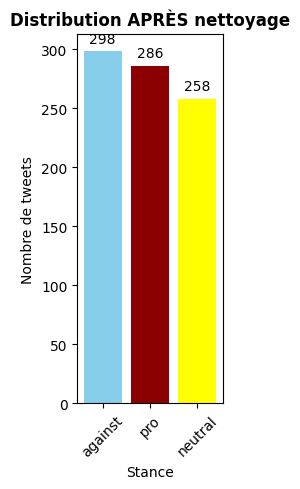

In [ ]:
# Premier subplot - Distribution après nettoyage
plt.subplot(1, 3, 1)
bars_final = plt.bar(final_counts.index, final_counts.values,
                     color=['skyblue', 'darkred', 'yellow'])
plt.title('Distribution APRÈS nettoyage', fontweight='bold')
plt.xlabel('Stance')
plt.ylabel('Nombre de tweets')
plt.xticks(rotation=45)

for bar in bars_final:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}', ha='center', va='bottom')


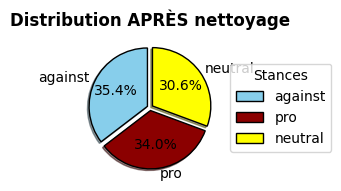

In [ ]:
# Deuxième subplot - Camembert après nettoyage
plt.subplot(1, 3, 2)
explode_final = [0.05 for _ in range(len(final_counts))]
wedges_final, texts_final, autotexts_final = plt.pie(final_counts.values,
                                                     labels=final_counts.index,
                                                     autopct='%1.1f%%',
                                                     explode=explode_final,
                                                     startangle=90,
                                                     colors=['skyblue', 'darkred', 'yellow'],
                                                     shadow=True,
                                                     wedgeprops={'edgecolor': 'black'})
plt.title('Distribution APRÈS nettoyage', fontweight='bold')
plt.legend(wedges_final, final_counts.index, title="Stances", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

(array([0, 1, 2]),
 [Text(0, 0, 'against'), Text(1, 0, 'pro'), Text(2, 0, 'neutral')])

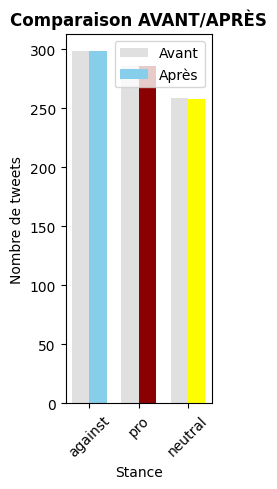

In [ ]:
# Troisième subplot - Comparaison avant/après
plt.subplot(1, 3, 3)
x = np.arange(len(initial_counts.index))
width = 0.35

bars_before = plt.bar(x - width/2, initial_counts.values, width, label='Avant', color='lightgray', alpha=0.7)
bars_after = plt.bar(x + width/2, final_counts.values, width, label='Après', color=['skyblue', 'darkred', 'yellow'])

plt.title('Comparaison AVANT/APRÈS', fontweight='bold')
plt.xlabel('Stance')
plt.ylabel('Nombre de tweets')
plt.xticks(x, initial_counts.index)
plt.legend()
plt.xticks(rotation=45)


In [ ]:
#(a corriger) Ajouter les valeurs
for i, (bar_before, bar_after) in enumerate(zip(bars_before, bars_after)):
    plt.text(bar_before.get_x() + bar_before.get_width()/2., bar_before.get_height() + 5,
             f'{initial_counts.values[i]}', ha='center', va='bottom', fontsize=9)
    plt.text(bar_after.get_x() + bar_after.get_width()/2., bar_after.get_height() + 5,
             f'{final_counts.values[i]}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Résumé final
print("\n" + "=" * 60)
print("RÉSUMÉ FINAL")
print("=" * 60)
print(f"Tweets initiaux: {len(df):,}")
print(f"Tweets après nettoyage: {len(df_clean):,}")
print(f"Tweets supprimés: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")
print(f"\nDistribution finale:")
for stance, count in final_counts.items():
    percentage = (count / len(df_clean)) * 100
    print(f"  {stance}: {count:,} tweets ({percentage:.1f}%)")

print("\n" + "=" * 60)


RÉSUMÉ FINAL
Tweets initiaux: 843
Tweets après nettoyage: 842
Tweets supprimés: 1 (0.1%)

Distribution finale:
  against: 298 tweets (35.4%)
  pro: 286 tweets (34.0%)
  neutral: 258 tweets (30.6%)



In [22]:
###ancien code
def clean(df):
    df = remove_diacritics(df)
    df = normalize_arabic(df)
    df = remove_punctuations(df)
    df = remove_repeating_char(df)
    df= remove_english_word_and_numbers(df)
    df=clean_space(df)
    return df

In [23]:
arabic_punctuations = '''`÷« »×؛<>٩٨'٧٦٥٤٣٢١٠_()↗*•&^%][ـ،/:"؟.,'{}⋮≈~¦+|٪!”…“–ـ/[]%=#*+\•~@£·_{}©^®`→°€™›♥←×§″′Â█à…“★”–●â►−¢¬░¶↑±▾	═¦║―¥▓—‹─▒：⊕▼▪†■’▀¨▄♫☆é¯♦¤▲è¸Ã⋅‘∞∙）↓、│（»，♪╩╚³・╦╣╔╗▬❤ïØ¹≤‡₹´'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ     # Tatwil/Kashida
                         """, re.VERBOSE)


In [24]:
def remove_diacritics(df):
    df['Sentence'] = df['Sentence'].apply(lambda x: _remove_diacritics(x))
    return df
def _remove_diacritics(x):
    x = str(x)
    x = re.sub(arabic_diacritics, '', x)
    return x

def normalize_arabic(df):
    df['Sentence'] = df['Sentence'].apply(lambda x: _normalize_arabic(x))
    return df
def _normalize_arabic(x):
    x = str(x)
    # added space around puncts after replace
    x = re.sub("[إأآا]", "ا", x)
    x = re.sub("ى", "ي", x)
    x = re.sub("ؤ", "ء", x)
    x = re.sub("ئ", "ء", x)
    x = re.sub("ة", "ه", x)
    x = re.sub("گ", "ك", x)
    return x

def remove_punctuations(df):
    df['Sentence'] = df['Sentence'].apply(lambda x: _remove_punctuations(x))
    return df
def _remove_punctuations(x):
    x = str(x)
    #translator = str.maketrans(' ', ' ', punctuations_list)
    translator = str.maketrans(punctuations_list, ' '*len(punctuations_list))
    return x.translate(translator)

def remove_repeating_char(df):
    df['Sentence'] = df['Sentence'].apply(lambda x: _remove_repeating_char(x))
    return df
def _remove_repeating_char(x):
    x = str(x)
    return re.sub(r'(.)\1+', r'\1', x)

def remove_english_word_and_numbers(df):
    df['Sentence'] = df['Sentence'].apply(lambda x: _remove_english_word_and_numbers(x))
    return df
def _remove_english_word_and_numbers(x):
    x = str(x)
    return re.sub(r'[a-zA-Z0-9]+', '', x)

def clean_space(df):
    compiled_re = re.compile(r"\s+")
    df['Sentence'] = df["Sentence"].apply(lambda x: _clean_space(x, compiled_re))
    return df
def _clean_space(x, compiled_re):
    return compiled_re.sub(" ", x)

In [25]:
num_cores = 2
def df_parallelize_run(df, func, num_cores=2):
    df_split = np.array_split(df, num_cores)
    pool = Pool(num_cores)
    df = pd.concat(pool.map(func, df_split))
    pool.close()
    pool.join()
    return df


In [26]:
df = df_parallelize_run(df, clean)


In [27]:
num_cores = 2
def df_parallelize_run(df, func, num_cores=2):
    df_split = np.array_split(df, num_cores)
    pool = Pool(num_cores)
    df = pd.concat(pool.map(func, df_split))
    pool.close()
    pool.join()
    return df

In [28]:
df = df_parallelize_run(df, clean)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer


In [30]:
df = df[['Sentence', 'Topic', 'stance_label']]

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
# Vectorization (Convert text data to numbers).

Count_vec = CountVectorizer(max_features=5000)
x = Count_vec.fit_transform(df['Sentence'].apply(lambda x: np.str_(x)))

#data_features = Count_vec.fit_transform(df['text'])

data_features = x.toarray()

In [32]:
X = data_features
y = df['stance_label']  # This contains 'pro', 'against', 'neutral'

In [33]:
X_train, X_test, y_train, y_test =train_test_split (X, y, test_size=.4, random_state=0)


#Logistic Regression

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [35]:
# Create a logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [36]:
# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.6745562130177515
Confusion Matrix:
[[90 12 17]
 [33 66 13]
 [23 12 72]]
Classification Report:
              precision    recall  f1-score   support

     against       0.62      0.76      0.68       119
     neutral       0.73      0.59      0.65       112
         pro       0.71      0.67      0.69       107

    accuracy                           0.67       338
   macro avg       0.69      0.67      0.67       338
weighted avg       0.68      0.67      0.67       338



# 1. First, Check Class Distribution

In [44]:
print("Class distribution in training data:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in test data:")
print(y_test.value_counts(normalize=True))

Class distribution in training data:
stance_label
against    0.344554
pro        0.342574
neutral    0.312871
Name: proportion, dtype: float64

Class distribution in test data:
stance_label
against    0.366864
pro        0.334320
neutral    0.298817
Name: proportion, dtype: float64


# 2. Improve Logistic Regression with Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 200, 500, 1000],
    'class_weight': [None, 'balanced']
}

# Create grid search
grid_search = GridSearchCV(
    LogisticRegression(multi_class='auto'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

# Test best model
y_pred_best = best_model.predict(X_test)
print(f"Improved Accuracy: {accuracy_score(y_test, y_pred_best)}")

#Gradient boost



In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [38]:
# Create a Gradient Boosting Classifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')



Accuracy: 0.6331360946745562
Confusion Matrix:
[[90 14 15]
 [34 59 19]
 [28 14 65]]
Classification Report:
              precision    recall  f1-score   support

     against       0.59      0.76      0.66       119
     neutral       0.68      0.53      0.59       112
         pro       0.66      0.61      0.63       107

    accuracy                           0.63       338
   macro avg       0.64      0.63      0.63       338
weighted avg       0.64      0.63      0.63       338



In [39]:
from sklearn.tree import DecisionTreeClassifier

#Decision Tree

In [40]:
model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.5088757396449705
Confusion Matrix:
[[78 20 21]
 [48 43 21]
 [38 18 51]]
Classification Report:
              precision    recall  f1-score   support

     against       0.48      0.66      0.55       119
     neutral       0.53      0.38      0.45       112
         pro       0.55      0.48      0.51       107

    accuracy                           0.51       338
   macro avg       0.52      0.51      0.50       338
weighted avg       0.52      0.51      0.50       338



#SVM

In [41]:
from sklearn.svm import SVC

In [42]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Create a Support Vector Machine Classifier
model = SVC(kernel='linear', random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.6597633136094675
Confusion Matrix:
[[84 11 29]
 [24 58 19]
 [16 16 81]]
Classification Report:
              precision    recall  f1-score   support

     against       0.68      0.68      0.68       124
     neutral       0.68      0.57      0.62       101
         pro       0.63      0.72      0.67       113

    accuracy                           0.66       338
   macro avg       0.66      0.66      0.66       338
weighted avg       0.66      0.66      0.66       338



#Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
# Create a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.6124260355029586
Confusion Matrix:
[[90  8 26]
 [36 46 19]
 [29 13 71]]
Classification Report:
              precision    recall  f1-score   support

     against       0.58      0.73      0.65       124
     neutral       0.69      0.46      0.55       101
         pro       0.61      0.63      0.62       113

    accuracy                           0.61       338
   macro avg       0.63      0.60      0.60       338
weighted avg       0.62      0.61      0.61       338

